# 🎯 Ziel dieser Lektion: Backpropagation und Optimierung

**Was wollen wir erreichen?** 
Wir lernen, wie das Netzwerk aus seinen Fehlern lernt. Der Algorithmus "Backpropagation" (Rückführung des Fehlers) ist der wichtigste Lernmechanismus in der KI.

**Von wo nach wo? (Problem & Ziel)** 
- **Ausgangssituation (Gegeben):** Das Modell macht Vorhersagen, aber diese sind noch falsch. Der Fehler (Loss) ist sehr hoch.
- **Endziel (Gesucht):** Wir wollen den tiefsten Punkt im "Fehlergebirge" finden, also die Gewichte so anpassen, dass der Fehler minimal (fast 0) wird.

### 🛤️ Ablauf (Schritt-für-Schritt)
`Vorhersage machen (Forward Pass)` ➔ `Fehler berechnen` ➔ `Fehler rückwärts durchs Netz senden (Backward Pass)` ➔ `Gradienten (Steigung) berechnen` ➔ `Gewichte durch den Optimierer verbessern`


## Exercise 1

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `def sigmoid(x): return 1 / (1 + np.exp(-np.clip...` | Berechnet die Exponentialfunktion (e^x). Dies ist ein wichtiger Baustein für viele Aktivierungsfunktionen wie Sigmoid. |
| `def sigmoid_abl(x): s = sigmoid(x); return s*(1-s)` | Definiert eine eigene Funktion. Das bedeutet, wir erstellen einen wiederverwendbaren Codeblock, der eine bestimmte Aufgabe erledigt. |
| `np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `W1 = np.array([[0.15, 0.25], [0.20, 0.30]])` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `print("=== Backpropagation – Schritt fuer Schri...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `W2_neu = W2 - lernrate * d_verlust_W2.reshape(1...` | Ändert die Dimensionen oder Form der Daten, ohne die Daten selbst zu verändern (z.B. aus einer Liste eine 2x2 Matrix machen). |


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Anfänger
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Step-by-step backpropagation for a simple 2-layer network
import numpy as np

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def sigmoid_abl(x): s = sigmoid(x); return s*(1-s)

# Netzwerk: 2 Eingaben -> 2 versteckt -> 1 Ausgabe
# Feste Gewichte aus dem klassischen Backprop-Beispiel (Rumelhart et al.)
np.random.seed(42)
W1 = np.array([[0.15, 0.25], [0.20, 0.30]])
b1 = np.array([0.35, 0.35])
W2 = np.array([[0.40, 0.50]])
b2 = np.array([0.60])
lernrate = 0.5

X = np.array([0.05, 0.10])
y_ziel = 0.01

print("=== Backpropagation – Schritt fuer Schritt ===")
print(f"\nEingabe: {X}, Ziel: {y_ziel}")

# ---- VORWÄRTSDURCHLAUF ----
z1 = W1 @ X + b1          # Vorwärtsdurchlauf Schicht 1
a1 = sigmoid(z1)           # Aktivierung Schicht 1
z2 = W2 @ a1 + b2          # Vorwärtsdurchlauf Schicht 2
a2 = sigmoid(z2)           # Aktivierung Ausgabe

print(f"\n--- Vorwaertsdurchlauf ---")
print(f"z1 = W1*X + b1 = {z1.round(6)}")
print(f"a1 = sigmoid(z1) = {a1.round(6)}")
print(f"z2 = W2*a1 + b2 = {z2.round(6)}")
print(f"a2 = sigmoid(z2) = {a2.round(6)}")
verlust = 0.5 * (y_ziel - a2[0])**2
print(f"MSE Verlust = {verlust:.6f}")

# ---- RÜCKWÄRTSDURCHLAUF ----
print(f"\n--- Rueckwaertsdurchlauf ---")

# Gradient an der Ausgabe
d_verlust_a2 = -(y_ziel - a2[0])          # dL/da2
d_a2_z2 = sigmoid_abl(z2[0])              # da2/dz2
delta2 = d_verlust_a2 * d_a2_z2           # dL/dz2
print(f"delta_Ausgabe = {delta2:.6f}")

# Gradient bezüglich W2 und b2
d_verlust_W2 = delta2 * a1
d_verlust_b2 = delta2
print(f"dL/dW2 = {d_verlust_W2.round(6)}")

# Gradient zurück durch versteckte Schicht
delta1 = (W2[0] * delta2) * sigmoid_abl(z1)
d_verlust_W1 = np.outer(delta1, X)
print(f"delta_versteckt = {delta1.round(6)}")
print(f"dL/dW1 =\n{d_verlust_W1.round(6)}")

# ---- GEWICHTS-UPDATE ----
W1_neu = W1 - lernrate * d_verlust_W1
W2_neu = W2 - lernrate * d_verlust_W2.reshape(1,-1)
print(f"\n--- Gewichts-Update (lr={lernrate}) ---")
print(f"W1_neu =\n{W1_neu.round(6)}")
print(f"W2_neu = {W2_neu.round(6)}")

# Neue Vorhersage nach Update
z1_neu = W1_neu @ X + b1; a1_neu = sigmoid(z1_neu)
z2_neu = W2_neu @ a1_neu + b2; a2_neu = sigmoid(z2_neu)
verlust_neu = 0.5 * (y_ziel - a2_neu[0])**2
print(f"\nVerlust vorher: {verlust:.6f}")
print(f"Verlust nachher: {verlust_neu:.6f}")
print(f"Verbesserung: {verlust - verlust_neu:.6f}")


=== Backpropagation – Schritt fuer Schritt ===

Eingabe: [0.05 0.1 ], Ziel: 0.01

--- Vorwaertsdurchlauf ---
z1 = W1*X + b1 = [0.3825 0.39  ]
a1 = sigmoid(z1) = [0.594476 0.596283]
z2 = W2*a1 + b2 = [1.135932]
a2 = sigmoid(z2) = [0.756932]
MSE Verlust = 0.278954

--- Rueckwaertsdurchlauf ---
delta_Ausgabe = 0.137425
dL/dW2 = [0.081696 0.081944]
delta_versteckt = [0.013252 0.016541]
dL/dW1 =
[[0.000663 0.001325]
 [0.000827 0.001654]]

--- Gewichts-Update (lr=0.5) ---
W1_neu =
[[0.149669 0.249337]
 [0.199586 0.299173]]
W2_neu = [[0.359152 0.459028]]

Verlust vorher: 0.278954
Verlust nachher: 0.272214
Verbesserung: 0.006739


## Exercise 2

**Dataset Used:** Synthetic Moons Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_moons` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_moons(n_samples=500, noise=0.2, ran...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `for lr in lernraten:` | Eine Schleife (Loop). Wiederholt einen bestimmten Codeblock für jedes Element in einer Liste oder für eine bestimmte Anzahl von Durchläufen (z.B. Epochen). |
| `tf.keras.layers.Dense(16, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `loss='binary_crossentropy', metrics=['accuracy'])` | Setzt die binäre Kreuzentropie als Fehlerfunktion, ideal für Probleme mit nur zwei Klassen (Ja/Nein). |
| `print(f"LR={lr:.3f}: finaler Verlust={h.history...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


C:\Users\esmae\Documents\Educx Neuronale Netze\NN_Projekt_Workspace\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR=0.001: finaler Verlust=0.4147, Genauigkeit=86.00%


LR=0.010: finaler Verlust=0.2769, Genauigkeit=86.00%


LR=0.100: finaler Verlust=0.0528, Genauigkeit=98.00%


LR=1.000: finaler Verlust=0.0545, Genauigkeit=98.00%


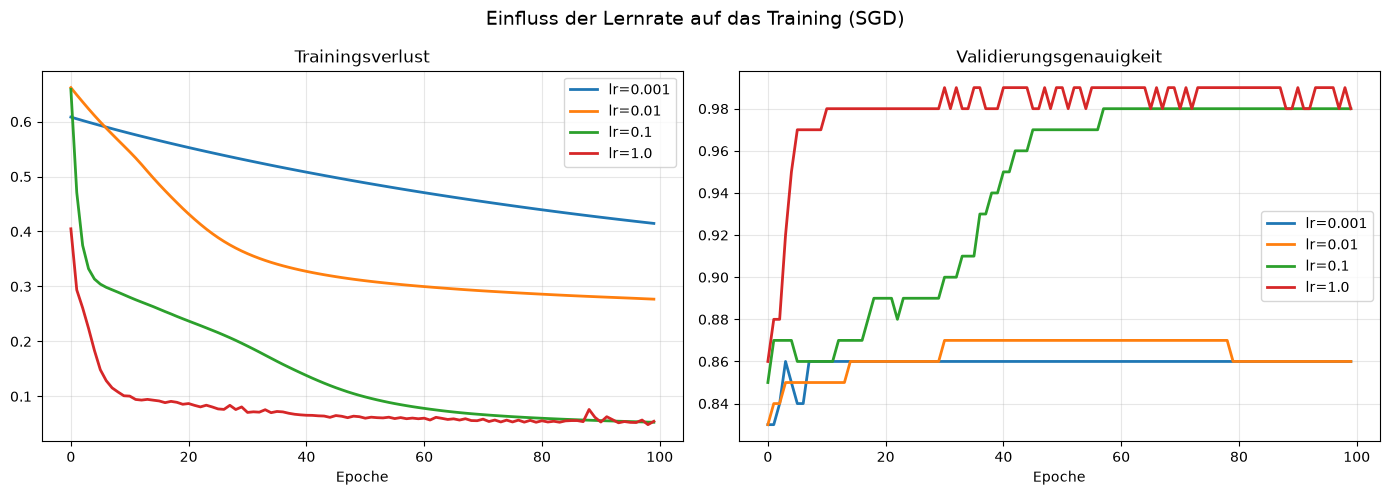

Lernratenvergleich gespeichert: lernrate_einfluss.png
Empfehlung: lr=0.01 ist oft ein guter Startpunkt fuer SGD


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Anfänger
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize the effect of different learning rates on training
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# Verschiedene Lernraten testen
lernraten = [0.001, 0.01, 0.1, 1.0]
ergebnisse = {}

for lr in lernraten:
    tf.random.set_seed(42)
    modell = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    modell.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                   loss='binary_crossentropy', metrics=['accuracy'])
    h = modell.fit(X_train, y_train, epochs=100, verbose=0, validation_data=(X_test, y_test))
    ergebnisse[lr] = h.history
    print(f"LR={lr:.3f}: finaler Verlust={h.history['loss'][-1]:.4f}, Genauigkeit={h.history['val_accuracy'][-1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Einfluss der Lernrate auf das Training (SGD)', fontsize=14)

for lr, hist in ergebnisse.items():
    axes[0].plot(hist['loss'], label=f'lr={lr}', linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=f'lr={lr}', linewidth=2)

for ax, titel in zip(axes, ['Trainingsverlust', 'Validierungsgenauigkeit']):
    ax.set_title(titel); ax.set_xlabel('Epoche')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lernrate_einfluss.png', dpi=100)
plt.show()
print("Lernratenvergleich gespeichert: lernrate_einfluss.png")
print("Empfehlung: lr=0.01 ist oft ein guter Startpunkt fuer SGD")


## Exercise 3

**Dataset Used:** Synthetic Circles Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

### Zeile-für-Zeile Code-Erklärung

| Code-Zeile | Was macht dieser Code auf Deutsch? |
|---|---|
| `%matplotlib inline` | Ein spezieller Jupyter-Notebook-Befehl, der dafür sorgt, dass generierte Diagramme direkt im Notebook angezeigt werden. |
| `import numpy as np` | Lädt die Bibliothek NumPy, die für komplexe mathematische Berechnungen mit Arrays und Matrizen verwendet wird. |
| `import matplotlib` | Lädt die grundlegende matplotlib-Bibliothek für Diagramme. |
| `import matplotlib.pyplot as plt` | Lädt die Bibliothek matplotlib, die zum Zeichnen von Graphen und Diagrammen benötigt wird. |
| `import tensorflow as tf` | Lädt TensorFlow, das Haupt-Framework von Google zum Erstellen und Trainieren von neuronalen Netzen. |
| `from sklearn.datasets import make_circles` | Importiert spezifische Funktionen oder Klassen aus einer anderen Bibliothek, um den Code kürzer zu machen. |
| `tf.random.set_seed(42); np.random.seed(42)` | Führt eine spezifische Berechnungsoperation, Datenmanipulation oder Funktion aus. |
| `X, y = make_circles(n_samples=600, noise=0.1, f...` | Definiert eine Variable oder speichert ein berechnetes Ergebnis in einer Variablen ab, um es später im Code wiederzuverwenden. |
| `tf.keras.layers.Dense(32, activation='relu', in...` | Fügt eine dicht vernetzte Schicht hinzu (Fully Connected Layer), in der jedes Neuron mit allen Neuronen der vorherigen Schicht verbunden ist. |
| `m.compile(optimizer=opt, loss='binary_crossentr...` | Setzt die binäre Kreuzentropie als Fehlerfunktion, ideal für Probleme mit nur zwei Klassen (Ja/Nein). |
| `print(f"{name:15s}: finale Testgenauigkeit = {h...` | Gibt den Wert der Variablen oder den angegebenen Text auf dem Bildschirm aus, damit wir das Ergebnis sehen können. |
| `plt.show()` | Sorgt dafür, dass das fertig gezeichnete Diagramm jetzt auf dem Bildschirm angezeigt wird. |


C:\Users\esmae\Documents\Educx Neuronale Netze\NN_Projekt_Workspace\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD            : finale Testgenauigkeit = 100.00%


SGD Momentum   : finale Testgenauigkeit = 100.00%


RMSprop        : finale Testgenauigkeit = 100.00%


Adam           : finale Testgenauigkeit = 100.00%


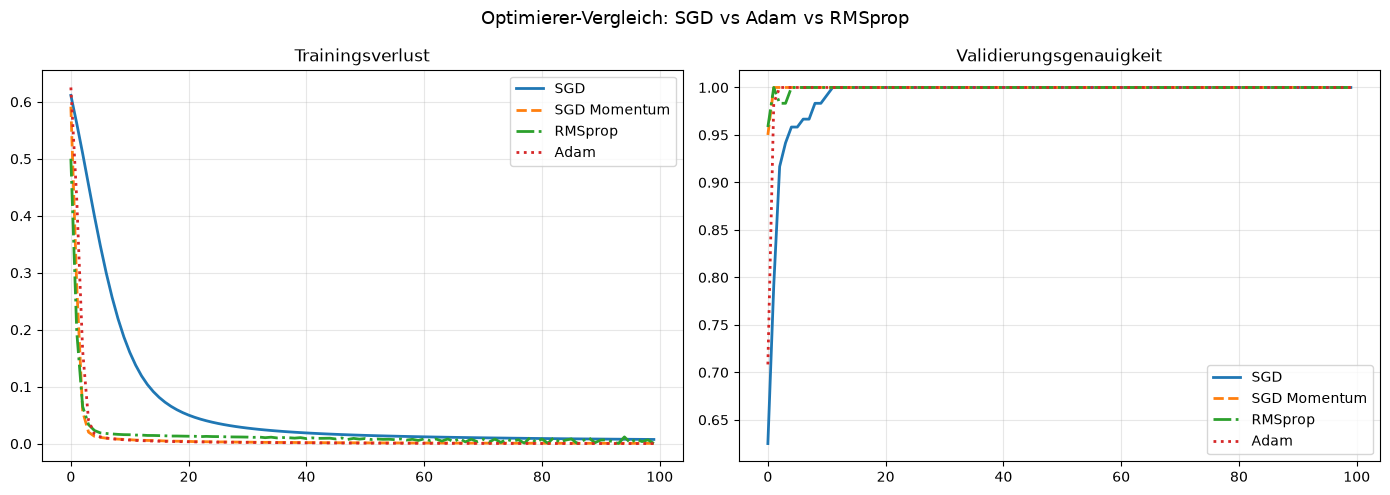

Optimierervergleich gespeichert: optimierer_vergleich.png


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 5: Backpropagation & Gradientenabstieg
# Niveau: Anfänger
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Compare SGD, Adam, RMSprop optimizers
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42); np.random.seed(42)

X, y = make_circles(n_samples=600, noise=0.1, factor=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train); X_test = scaler.transform(X_test)

# Verschiedene Optimierer vergleichen
optimierer = {
    'SGD':          lambda: tf.keras.optimizers.SGD(learning_rate=0.1),
    'SGD Momentum': lambda: tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    'RMSprop':      lambda: tf.keras.optimizers.RMSprop(learning_rate=0.01),
    'Adam':         lambda: tf.keras.optimizers.Adam(learning_rate=0.01),
}

ergebnisse = {}
for name, opt_fn in optimierer.items():
    tf.random.set_seed(42)
    opt = opt_fn()
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(2,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train, y_train, epochs=100, verbose=0, validation_data=(X_test, y_test))
    ergebnisse[name] = h.history
    print(f"{name:15s}: finale Testgenauigkeit = {h.history['val_accuracy'][-1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stile = ['-', '--', '-.', ':']
for (name, hist), stil in zip(ergebnisse.items(), stile):
    axes[0].plot(hist['loss'],         label=name, linestyle=stil, linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=name, linestyle=stil, linewidth=2)

for ax, t in zip(axes, ['Trainingsverlust', 'Validierungsgenauigkeit']):
    ax.set_title(t); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Optimierer-Vergleich: SGD vs Adam vs RMSprop', fontsize=13)
plt.tight_layout()
plt.savefig('optimierer_vergleich.png', dpi=100)
plt.show()
print("Optimierervergleich gespeichert: optimierer_vergleich.png")
